# Analyse des hospitalisations — TP Data Visualisation

## Objectifs du TP
1. Explorer et visualiser les données  
2. Identifier les tendances importantes  
3. Analyser les facteurs influençant les coûts et la durée d’hospitalisation  
4. Construire un modèle de machine learning pour prédire un indicateur hospitalier  
5. Interpréter les résultats dans un rapport analytique  

**Livrables couverts :** notebook (nettoyage, visualisations, ML) ; base pour le **rapport analytique** (3–5 pages) : données, EDA, graphiques, modèles, interprétation, conclusion.


Imports

In [34]:
import sys
from pathlib import Path

# Racine du projet : permet d'importer `source` quand le notebook est dans notebooks/
_root = Path.cwd()
if _root.name == "notebooks":
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import src.config as _cfg
import src.data_loader as _dl
import src.preprocessing as _prep

from src.config import DATA_FILE, TEST_SIZE, RANDOM_STATE
from src.data_loader import (
    load_data,
    get_head,
    get_shape,
    get_columns,
    get_dtypes,
    get_missing_values,
    get_descriptive_stats,
)
from src.feature_engineering import create_long_stay_target
from src.evaluation import evaluate_regression, evaluate_classification
from src.ml_importance import (
    regression_permutation_importance,
    classification_permutation_importance,
)

from src.visualization.exploration_viz import (
    plot_age_distribution,
    plot_gender_distribution,
    plot_top_departments,
    plot_top_diseases,
)
from src.visualization.charts_extra import plot_gender_pie
from src.visualization.duration_plots import plot_mean_stay_by_disease
from src.visualization.hospitalisation_viz import (
    plot_stay_by_department,
    plot_treatment_distribution,
    plot_age_vs_stay,
)
from src.visualization.cost_viz import (
    plot_cost_by_department,
    plot_top_costly_diseases,
    plot_stay_vs_cost,
    plot_cost_by_treatment,
)

from src.models.regression import (
    build_regression_preprocessor,
    get_regression_models,
)
from src.models.classification import (
    build_classification_preprocessor,
    get_classification_models,
)

importlib.reload(_cfg)
importlib.reload(_dl)
importlib.reload(_prep)
clean_data = _prep.clean_data

sns.set_theme(style="whitegrid")

Chargement des données

In [36]:
importlib.reload(_cfg)
importlib.reload(_dl)
importlib.reload(_prep)
clean_data = _prep.clean_data

# Chemins, CSV et colonnes à jour (évite d’anciens modules en mémoire)
df = clean_data(_dl.load_data(DATA_FILE))

print("Dimensions :", get_shape(df))
print("Colonnes :", get_columns(df))
display(get_head(df))
display(get_dtypes(df))
display(get_missing_values(df))
display(get_descriptive_stats(df))

Dimensions : (500, 10)
Colonnes : ['patient_id', 'age', 'gender', 'department', 'disease', 'duration_of_stay', 'cost', 'date_admission', 'date_discharge', 'treatment']


,patient_id,age,gender,department,disease,duration_of_stay,cost,date_admission,date_discharge,treatment
0,1,82,M,Cardiologie,Cancer,5,2125,03/09/2025,08/09/2025,Chirurgie
1,2,18,M,Oncologie,Cancer,15,8685,16/01/2025,31/01/2025,Médication
2,3,76,F,Cardiologie,Infarctus,2,822,17/05/2025,19/05/2025,Chirurgie
3,4,65,M,Neurologie,Fracture,12,7584,08/06/2025,20/06/2025,Physiothérapie
4,5,70,F,Orthopédie,Alzheimer,10,4420,01/10/2025,11/10/2025,Médication


patient_id          int64
age                 int64
gender                str
department            str
disease               str
duration_of_stay    int64
cost                int64
date_admission        str
date_discharge        str
treatment             str
dtype: object

patient_id          0
age                 0
gender              0
department          0
disease             0
duration_of_stay    0
cost                0
date_admission      0
date_discharge      0
treatment           0
dtype: int64

,patient_id,age,gender,department,disease,duration_of_stay,cost,date_admission,date_discharge,treatment
count,500.000000,500.000000,500,500,500,500.000000,500.000000,500,500,500
unique,NaN,NaN,2,7,7,NaN,NaN,280,283,6
top,NaN,NaN,M,Oncologie,Eczéma,NaN,NaN,24/10/2025,23/12/2024,Physiothérapie
freq,NaN,NaN,252,90,89,NaN,NaN,6,5,89
mean,250.500000,47.182000,NaN,NaN,NaN,7.954000,4060.118000,NaN,NaN,NaN
std,144.481833,25.045867,NaN,NaN,NaN,4.210861,2418.813226,NaN,NaN,NaN
min,1.000000,1.000000,NaN,NaN,NaN,1.000000,303.000000,NaN,NaN,NaN
25%,125.750000,27.000000,NaN,NaN,NaN,5.000000,2136.250000,NaN,NaN,NaN
50%,250.500000,49.000000,NaN,NaN,NaN,8.000000,3769.500000,NaN,NaN,NaN
75%,375.250000,69.000000,NaN,NaN,NaN,12.000000,5749.500000,NaN,NaN,NaN


### Partie 1 — Exploration des données
Histogrammes, barres, diagramme circulaire (camembert).

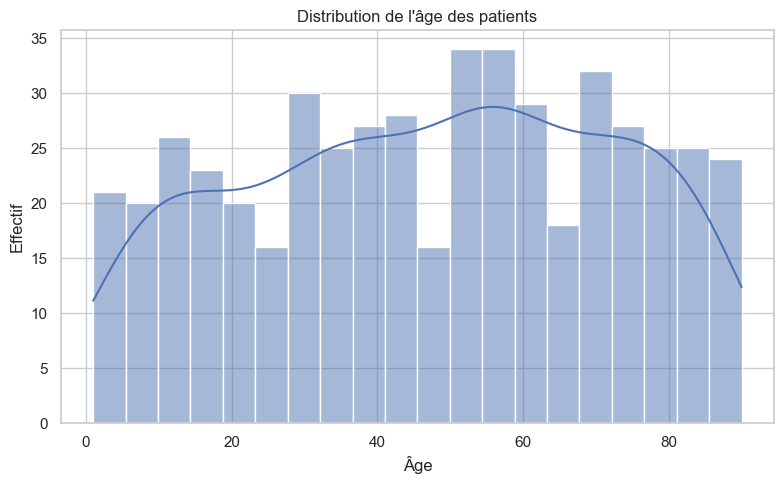

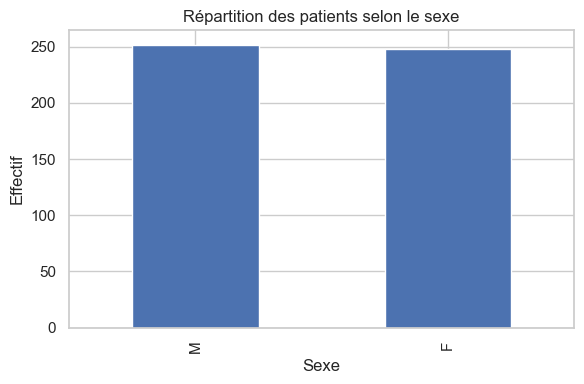

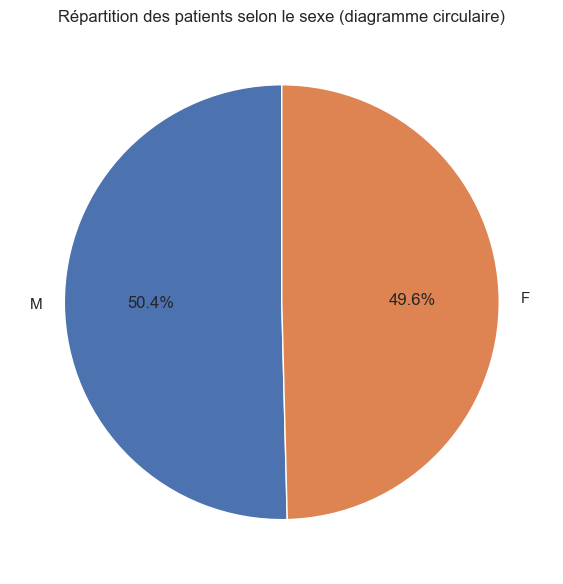

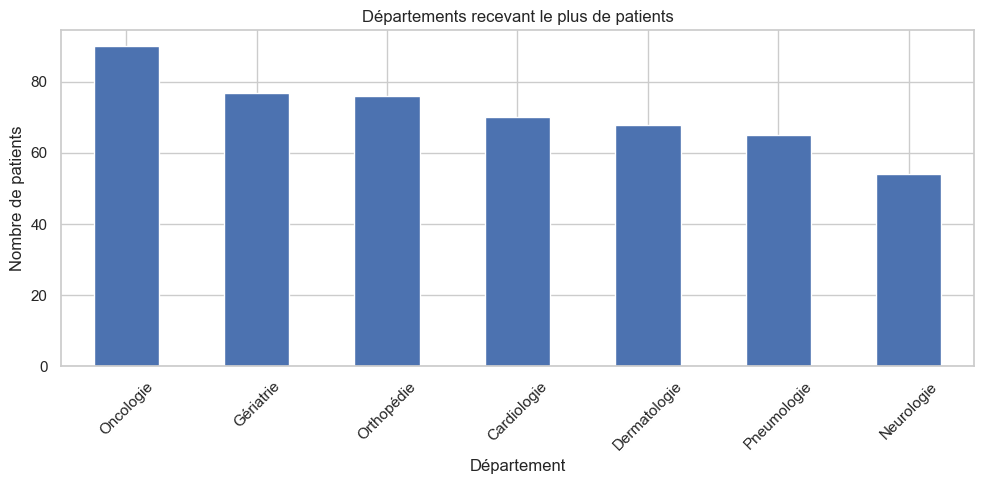

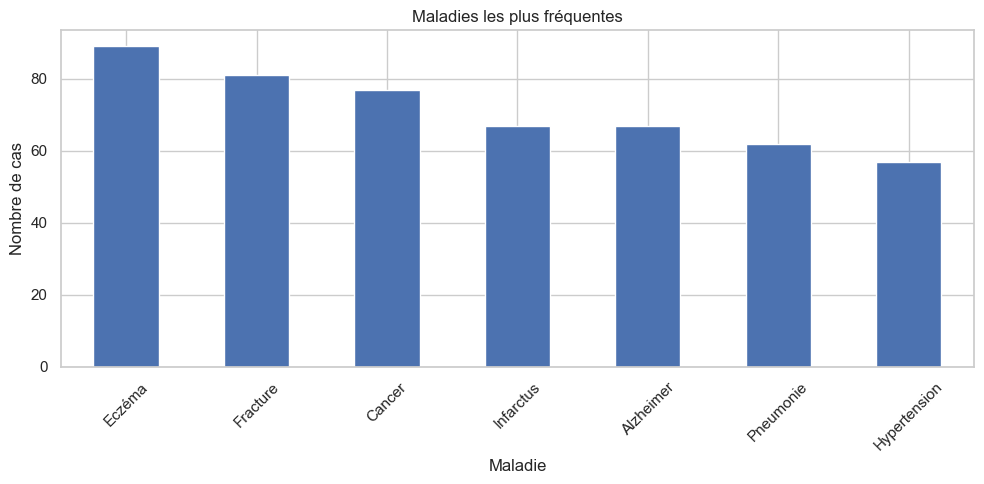

In [42]:
plot_age_distribution(df, age_col="age")
plot_gender_distribution(df, gender_col="gender")
plot_gender_pie(df, gender_col="gender")
plot_top_departments(df, dept_col="department")
plot_top_diseases(df, disease_col="disease")

### Partie 2 — Hospitalisations
Durée moyenne, comparaisons par département et par maladie, traitements, lien âge / durée (boxplot, barres, nuage de points).

Durée moyenne de séjour : 7.954


department
Orthopédie      8.302632
Oncologie       8.077778
Gériatrie       8.051948
Neurologie      8.037037
Pneumologie     7.815385
Dermatologie    7.720588
Cardiologie     7.600000
Name: duration_of_stay, dtype: float64

disease
Alzheimer       8.358209
Infarctus       8.253731
Pneumonie       7.983871
Fracture        7.851852
Cancer          7.831169
Hypertension    7.754386
Eczéma          7.730337
Name: duration_of_stay, dtype: float64

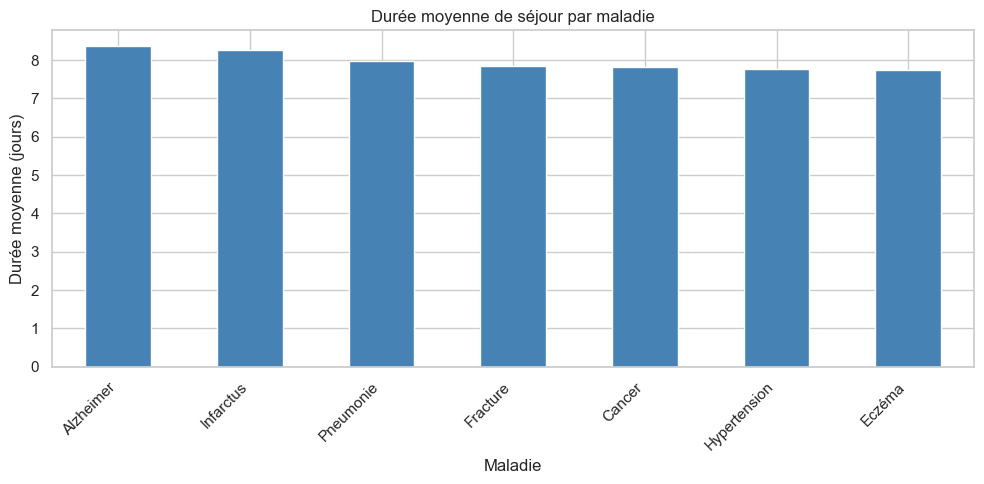

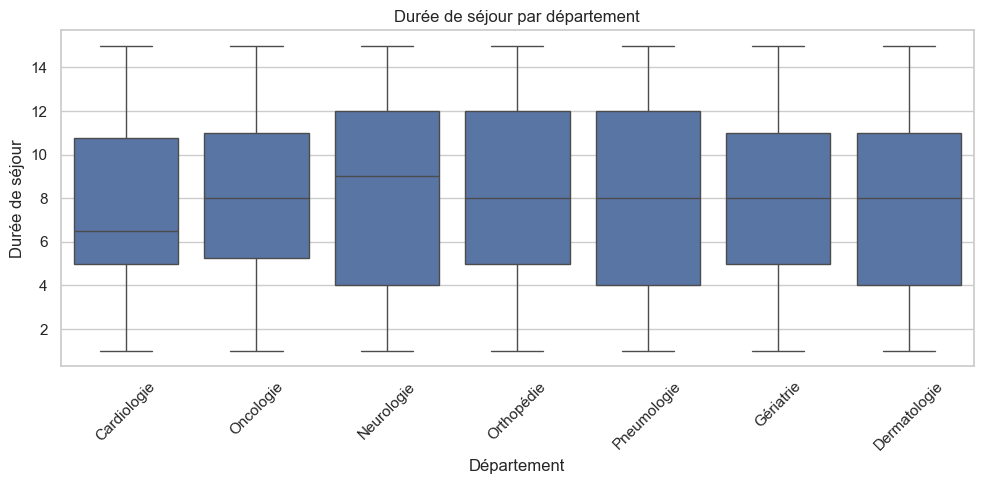

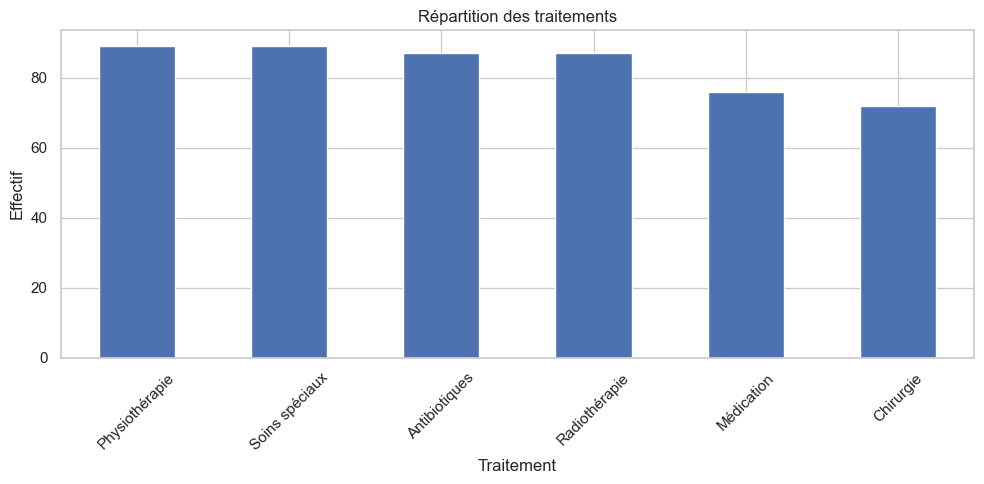

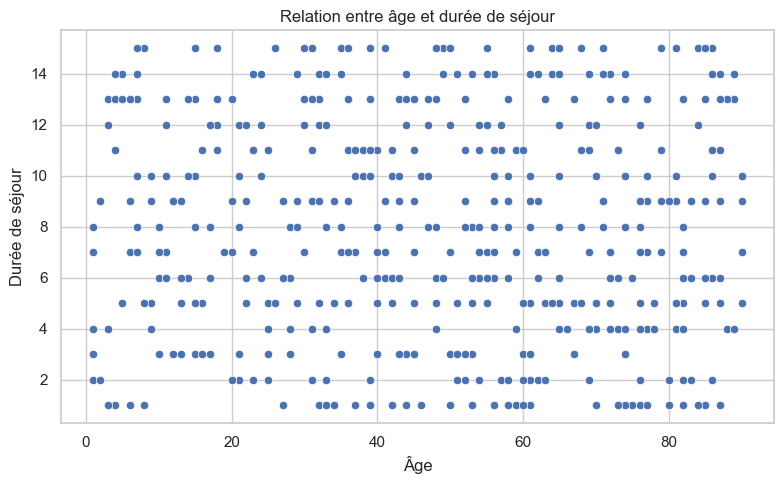

In [43]:
print("Durée moyenne de séjour :", df["duration_of_stay"].mean())

avg_stay_by_dept = df.groupby("department")["duration_of_stay"].mean().sort_values(ascending=False)
display(avg_stay_by_dept)

avg_stay_by_disease = df.groupby("disease")["duration_of_stay"].mean().sort_values(ascending=False)
display(avg_stay_by_disease.head(10))

plot_mean_stay_by_disease(df, disease_col="disease", stay_col="duration_of_stay")

plot_stay_by_department(df, dept_col="department", stay_col="duration_of_stay")
plot_treatment_distribution(df, treatment_col="treatment")
plot_age_vs_stay(df, age_col="age", stay_col="duration_of_stay")

### Partie 3 — Coûts
Moyennes, comparaisons par département et traitement, maladies les plus coûteuses, lien durée / coût (boxplots, barres, nuage de points).

Coût moyen d’hospitalisation : 4060.118


department
Oncologie       4306.022222
Gériatrie       4222.493506
Orthopédie      4070.565789
Neurologie      3995.074074
Pneumologie     3987.015385
Dermatologie    3884.264706
Cardiologie     3842.885714
Name: cost, dtype: float64

disease
Alzheimer       4320.910448
Infarctus       4234.059701
Fracture        4207.148148
Pneumonie       4143.419355
Cancer          3904.532468
Eczéma          3862.988764
Hypertension    3767.543860
Name: cost, dtype: float64

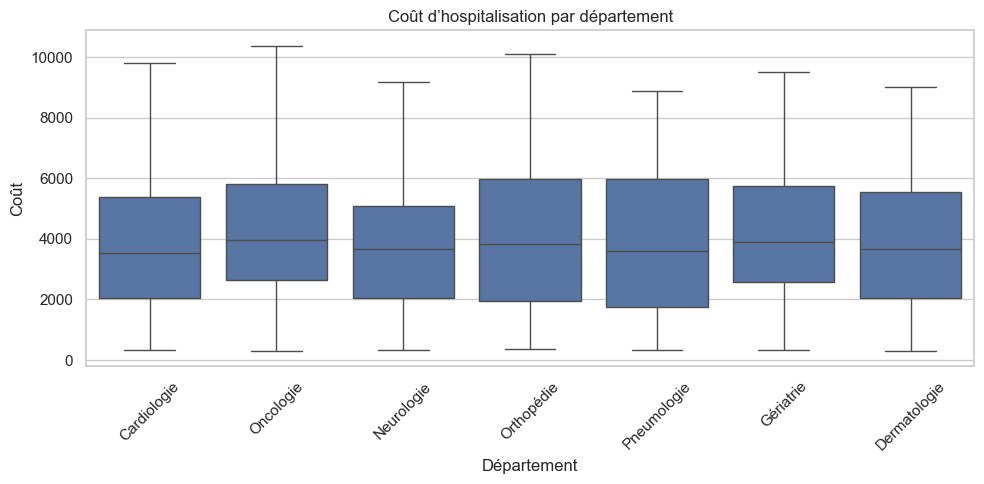

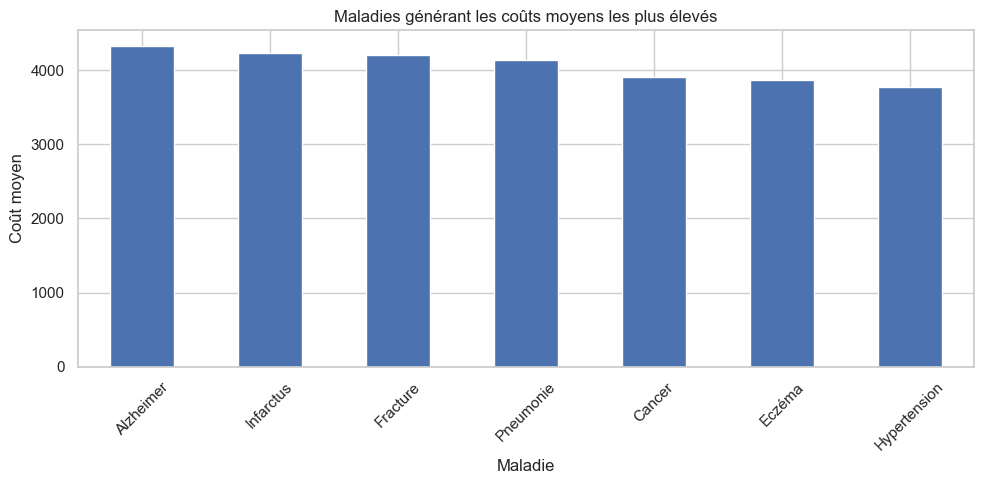

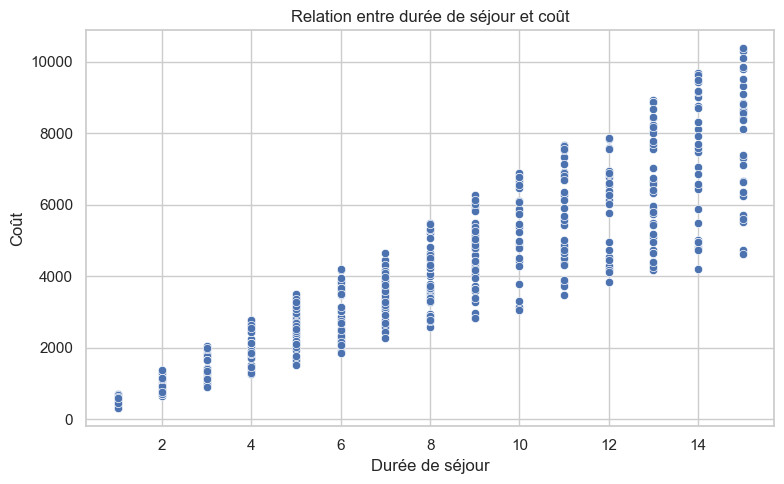

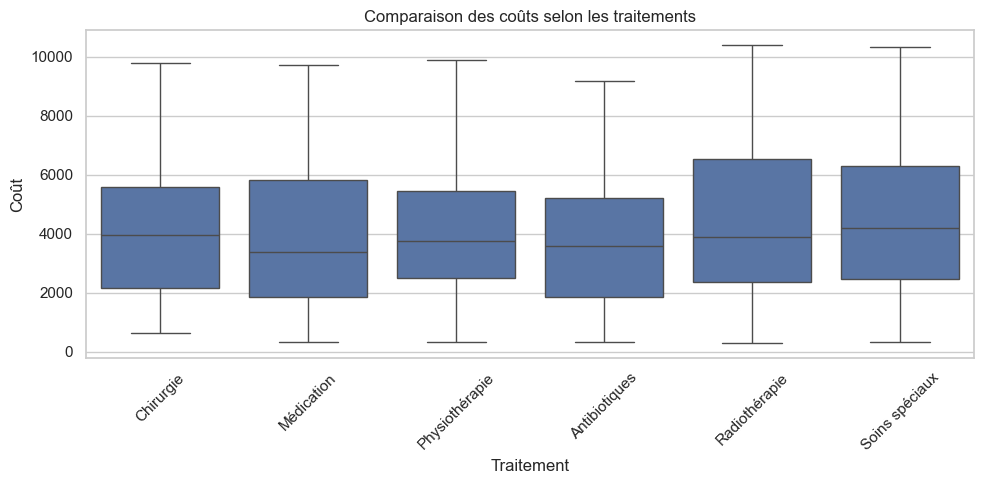

In [44]:
print("Coût moyen d’hospitalisation :", df["cost"].mean())

avg_cost_by_dept = df.groupby("department")["cost"].mean().sort_values(ascending=False)
display(avg_cost_by_dept)

avg_cost_by_disease = df.groupby("disease")["cost"].mean().sort_values(ascending=False)
display(avg_cost_by_disease.head(10))

plot_cost_by_department(df, dept_col="department", cost_col="cost")
plot_top_costly_diseases(df, disease_col="disease", cost_col="cost")
plot_stay_vs_cost(df, stay_col="duration_of_stay", cost_col="cost")
plot_cost_by_treatment(df, treatment_col="treatment", cost_col="cost")

### Machine Learning — Option 1 : prédiction du coût (régression)
Modèles : régression linéaire, Random Forest, Gradient Boosting. Métriques : MAE, RMSE, R². Importance des variables (permutation).

In [45]:
importlib.reload(_prep)
clean_data = _prep.clean_data
df = clean_data(df)

target = "cost"
features = ["age", "gender", "department", "disease", "treatment", "duration_of_stay"]

X = df[features]
y = df[target]

numeric_features = ["age", "duration_of_stay"]
categorical_features = ["gender", "department", "disease", "treatment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

preprocessor = build_regression_preprocessor(numeric_features, categorical_features)
models = get_regression_models(preprocessor)

regression_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores = evaluate_regression(y_test, y_pred)
    scores["Model"] = model_name
    regression_results.append(scores)

regression_results = pd.DataFrame(regression_results)
display(regression_results.sort_values(by="R2", ascending=False))

best_reg_name = regression_results.sort_values(by="R2", ascending=False).iloc[0]["Model"]
best_reg = models[best_reg_name]
print("Modèle retenu pour l’importance des variables :", best_reg_name)
imp_reg = regression_permutation_importance(
    best_reg, X_test, y_test, features, random_state=RANDOM_STATE
)
display(imp_reg)

,MAE,RMSE,R2,Model
2,774.096830,980.766731,0.829876,GradientBoosting
0,792.097718,1016.211144,0.817357,LinearRegression
1,773.613475,1029.659641,0.812491,RandomForest


Modèle retenu pour l’importance des variables : GradientBoosting


,variable,importance_moyenne,importance_ecart_type
0,duration_of_stay,1.674865,0.248405
1,treatment,0.020904,0.007734
2,disease,0.011942,0.006839
3,department,0.005228,0.005840
4,age,0.004530,0.011424
5,gender,0.004398,0.001482


### Machine Learning — Option 2 : prédiction des séjours longs (classification)
Cible : séjour long = 1 si durée > moyenne. Modèles : régression logistique, Random Forest, arbre de décision. Métriques : accuracy, precision, recall, F1.

In [46]:
importlib.reload(_prep)
clean_data = _prep.clean_data
df = clean_data(df)

df_classif, threshold = create_long_stay_target(df, stay_column="duration_of_stay")

target = "long_stay"
features = ["age", "gender", "department", "disease", "treatment", "cost"]

X = df_classif[features]
y = df_classif[target]

numeric_features = ["age", "cost"]
categorical_features = ["gender", "department", "disease", "treatment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

preprocessor = build_classification_preprocessor(numeric_features, categorical_features)
models = get_classification_models(preprocessor)

classification_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores = evaluate_classification(y_test, y_pred)
    scores["Model"] = model_name
    classification_results.append(scores)

classification_results = pd.DataFrame(classification_results)
display(classification_results.sort_values(by="F1-score", ascending=False))

print("Seuil utilisé pour définir un séjour long :", threshold)

best_clf_name = classification_results.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
best_clf = models[best_clf_name]
print("Modèle retenu pour l’importance des variables :", best_clf_name)
imp_clf = classification_permutation_importance(
    best_clf, X_test, y_test, features, random_state=RANDOM_STATE
)
display(imp_clf)

,Accuracy,Precision,Recall,F1-score,Model
1,0.92,0.941176,0.905660,0.923077,RandomForestClassifier
0,0.91,0.892857,0.943396,0.917431,LogisticRegression
2,0.91,0.892857,0.943396,0.917431,DecisionTreeClassifier


Seuil utilisé pour définir un séjour long : 7.954
Modèle retenu pour l’importance des variables : RandomForestClassifier


,variable,importance_moyenne,importance_ecart_type
0,cost,0.416000,0.063330
1,department,0.005333,0.014079
2,treatment,0.003333,0.007888
3,age,0.002000,0.006532
4,disease,-0.006667,0.011353
5,gender,-0.010667,0.006799


## 6. Interprétation des résultats

### 6.1 Quels facteurs expliquent les coûts hospitaliers ?

L’**importance par permutation** sur le meilleur modèle de régression (**Gradient Boosting**, R² ≈ **0,83** sur le jeu test) montre que la **durée de séjour** domine largement : sa perte d’information fait chuter le R² d’environ **1,67** point en moyenne, ce qui est cohérent avec une logique de coûts liés au temps d’occupation des lits et aux actes cumulés. Viennent ensuite, avec des effets **nettement plus faibles** mais non nuls, le **type de traitement**, la **maladie**, le **département**, puis **l’âge** et le **sexe**. Autrement dit, le **parcours clinique** (durée, filière, pathologie, actes) structure le coût bien plus que le seul profil démographique.

### 6.2 Quels profils ont les séjours les plus longs ?

La **durée moyenne globale** est d’environ **7,95 jours**. Les départements avec les durées moyennes les plus élevées sont notamment **Orthopédie** (~**8,3** j), **Oncologie** (~**8,1** j) et **Gériatrie** (~**8,1** j). Côté **maladies**, les durées moyennes les plus longues ressortent pour **Alzheimer** (~**8,4** j), **Infarctus** (~**8,3** j) et **Pneumonie** (~**8,0** j). Le nuage de points âge × durée (partie 2) permet de nuancer : la relation n’est pas strictement linéaire ; les séjours « longs » au sens du TP sont définis par **durée > moyenne** (seuil ≈ **7,95** j), ce qui partage à peu près **50 % / 50 %** des cas — choix méthodologique à mentionner dans un rapport métier (on pourrait préférer un seuil clinique ou un quantile).

### 6.3 Les modèles prédictifs sont-ils fiables ?

- **Régression (coût)** : trois modèles obtiennent un **R²** compris entre **~0,81** et **~0,83** avec une **RMSE** d’environ **980–1030** et une **MAE** d’environ **770–790** (sur l’échantillon test, `TEST_SIZE=0,2`, `RANDOM_STATE=42`). C’est **relativement bon** pour un jeu de 500 lignes, mais la **durée** comme variable explicative du coût peut **mecaniquement** renforcer le R² (effet attendu, à discuter comme limite d’interprétation « causalité »).
- **Classification (séjour long)** : la **forêt aléatoire** atteint environ **92 %** d’**accuracy** et un **F1** ≈ **0,92**. L’importance par permutation place le **coût** très en tête : c’est **cohérent** avec des séjours longs plus lourds financièrement, mais cela rapproche la cible (durée) et une variable fortement corrélée (coût) — à **nuancer** dans une perspective de modèle déployable (risque de redondance / fuite conceptuelle selon l’usage).

### 6.4 Comment l’hôpital pourrait-il optimiser ses ressources ?

- **Planifier la capacité** en fonction des départements et pathologies à **séjour moyen long** (orthopédie, oncologie, gériatrie ; Alzheimer, infarctus, pneumonie).  
- **Piloter la durée** (parcours, sorties, médico-social) pour contenir les coûts, puisque la durée est le **premier levier** identifié pour le coût.  
- **Analyser les traitements** à fort impact (chirurgie, médication, etc.) pour standardiser les protocoles ou négocier les approvisionnements.  
- Utiliser les modèles comme **outils d’aide** à la budgétisation ou à l’alerte, pas comme décision automatique sans relecture clinique.

---

## 7. Conclusion et recommandations

### Synthèse

Le jeu de données compte **500** hospitalisations et **10** variables (identité, âge, sexe, département, maladie, durée, coût, dates, traitement). L’exploration montre une **charge** importante en **oncologie**, **gériatrie** et **orthopédie**, et des pathologies variées (dont eczéma, fracture, cancer). Le **coût moyen** est d’environ **4 060** unités monétaires pour une **durée moyenne** d’environ **8 jours**. Les graphiques (histogrammes, barres, camembert, boxplots, nuages de points) mettent en évidence les **écarts entre départements et maladies** et le lien **durée–coût**.

### Modèles

La **régression** (cible : coût) confirme que le **Gradient Boosting** est légèrement supérieur sur le R² ; la **classification** (séjour long vs court) donne de **bonnes performances** avec la **forêt aléatoire**. Les importances de variables vont dans le sens attendu (**durée** pour le coût ; **coût** très visible pour prédire un séjour long).

### Recommandations pour le rapport et pour l’établissement

1. **Rapport (3–5 pages)** : intégrer les **chiffres ci-dessus**, **2–3 figures clés** (distribution âge, coûts par département, durée par maladie, dispersion durée–coût) et un **encadré limites** (échantillon unique, données pédagogiques, seuil « séjour long », corrélation coût–durée).  
2. **Poursuite possible** : tester d’autres seuils de séjour long, une validation croisée, ou retirer la durée (ou le coût) des prédicteurs selon la question métier posée.  
3. **Décisionnel** : prioriser le **pilotage des durées** et des **lits** sur les filières identifiées, et compléter par une revue **médico-économique** des **traitements** les plus impactants.

---

*Exécution de référence : pipeline `scripts/run_analysis.py` (figures dans `visuals/run_cli/`).*


In [25]:
print("=== Checklist rapport analytique (3–5 pages) ===")
print("1. Description des données (structure, types, effectifs)")
print("2. Analyse exploratoire (tendances, statistiques)")
print("3. Visualisations principales (cf. parties 1–3 du notebook)")
print("4. ML : régression (coût) + classification (séjour long), métriques, importance des variables")
print("5. Interprétation : section 6 (rédigée)")
print("6. Conclusion et recommandations : section 7 (rédigée)")

Résumé :
- Identifier les départements les plus sollicités
- Identifier les maladies les plus fréquentes
- Comprendre l’impact de l’âge, du traitement et de la durée sur le coût
- Comparer les performances des modèles
- Choisir le meilleur modèle selon les métriques
